In [1]:
import cv2
import numpy as np
import os
import glob
import pandas as pd
from tqdm.notebook import tqdm

# HAPUS BARIS INI: from rembg import remove

IMG_SIZE = (64, 64) 

def extract_features_sobel_no_bg(image_path):
    img = cv2.imread(image_path)
    if img is None:
        return None

    # 1. Menghapus Background dengan OpenCV murni (Otsu Thresholding)
    # Ubah citra asli ke grayscale untuk mencari bentuk objek
    gray_orig = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    # Blur untuk menghaluskan tekstur agar mask lebih rapi
    blur_orig = cv2.GaussianBlur(gray_orig, (5, 5), 0)
    
    # Menggunakan Otsu Thresholding untuk memisahkan background (diasumsikan background terang/putih)
    _, mask = cv2.threshold(blur_orig, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    
    # (Opsional) Operasi Morfologi untuk merapikan mask/menutup lubang kecil
    kernel = np.ones((5,5), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=2)
    
    # Aplikasikan mask ke citra asli (background akan otomatis menjadi hitam)
    img_rgb = cv2.bitwise_and(img, img, mask=mask)

    # 3. Normalisasi Dimensi
    img_resized = cv2.resize(img_rgb, IMG_SIZE)

    # 4. Grayscale & Blur (Untuk persiapan Sobel)
    img_gray = cv2.cvtColor(img_resized, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(img_gray, (5, 5), 0)

    # 5. Thresholding (Otsu) kedua untuk fitur
    _, binary = cv2.threshold(blurred, 10, 255, cv2.THRESH_BINARY | cv2.THRESH_OTSU)

    # 6. Deteksi Tepi (Sobel)
    sobelx = cv2.Sobel(binary, cv2.CV_64F, 1, 0, ksize=3)
    sobely = cv2.Sobel(binary, cv2.CV_64F, 0, 1, ksize=3)
    sobel_combined = np.uint8(np.absolute(cv2.magnitude(sobelx, sobely)))

    # 7. Flatten matriks
    features = sobel_combined.flatten()

    return features

# --- PROSES EKSTRAKSI DATA TRAIN ---
train_dir = "dataset/train"
categories = {"helm": 0, "kacamata": 1}

X_train_list = []
y_train_list = []

for label_name, label_id in categories.items():
    folder = os.path.join(train_dir, label_name)
    files = glob.glob(os.path.join(folder, "*.*"))
    print(f"Memproses '{label_name}': {len(files)} gambar ditemukan...")

    for img_path in tqdm(files, desc=f"Ekstraksi {label_name}"):
        features = extract_features_sobel_no_bg(img_path)
        if features is not None:
            X_train_list.append(features)
            y_train_list.append(label_id)

X = np.array(X_train_list)
y = np.array(y_train_list)

print(f"\nEkstraksi selesai! Dimensi Matriks Fitur (X): {X.shape}")


Memproses 'helm': 1436 gambar ditemukan...


Ekstraksi helm:   0%|          | 0/1436 [00:00<?, ?it/s]

Memproses 'kacamata': 720 gambar ditemukan...


Ekstraksi kacamata:   0%|          | 0/720 [00:00<?, ?it/s]


Ekstraksi selesai! Dimensi Matriks Fitur (X): (2156, 4096)


In [2]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier

# Split data untuk validasi (80% Train, 20% Val)
X_tr, X_val, y_tr, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Inisialisasi dan Pelatihan Model Random Forest
print("Melatih model Random Forest dengan fitur tepi citra...")
rf_model = RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=42, n_jobs=-1)
rf_model.fit(X_tr, y_tr)

# Evaluasi pada data validasi
val_acc = rf_model.score(X_val, y_val)
print(f"Akurasi pada data validasi internal (20%): {val_acc*100:.2f}%")

# Cross Validation
cv_scores = cross_val_score(rf_model, X, y, cv=5, scoring='accuracy', n_jobs=-1)
print(f"5-Fold CV Scores: {[round(s*100, 2) for s in cv_scores]}")
print(f"Rata-rata CV Accuracy: {cv_scores.mean()*100:.2f}%")

Melatih model Random Forest dengan fitur tepi citra...
Akurasi pada data validasi internal (20%): 87.73%
5-Fold CV Scores: [np.float64(68.98), np.float64(65.89), np.float64(68.21), np.float64(63.11), np.float64(67.52)]
Rata-rata CV Accuracy: 66.74%


In [ ]:
import matplotlib.pyplot as plt 

def classify_and_visualize_no_bg(image_path, model):
    img = cv2.imread(image_path)
    if img is None:
        return "Error"

    # 1. Menghapus Background dengan OpenCV murni (Sama seperti saat training)
    gray_orig = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blur_orig = cv2.GaussianBlur(gray_orig, (5, 5), 0)
    _, mask = cv2.threshold(blur_orig, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    
    kernel = np.ones((5,5), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=2)
    img_rgb = cv2.bitwise_and(img, img, mask=mask)

    # 3. Normalisasi Dimensi
    img_resized = cv2.resize(img_rgb, IMG_SIZE)

    # 4. Grayscale & Blur (Untuk persiapan Sobel)
    img_gray = cv2.cvtColor(img_resized, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(img_gray, (5, 5), 0)

    # 5. Thresholding (Otsu) kedua
    _, binary = cv2.threshold(blurred, 10, 255, cv2.THRESH_BINARY | cv2.THRESH_OTSU)

    # 6. Deteksi Tepi (Sobel)
    sobelx = cv2.Sobel(binary, cv2.CV_64F, 1, 0, ksize=3)
    sobely = cv2.Sobel(binary, cv2.CV_64F, 0, 1, ksize=3)
    sobel_combined = np.uint8(np.absolute(cv2.magnitude(sobelx, sobely)))

    # 7. Prediksi
    features = sobel_combined.flatten().reshape(1, -1)
    pred_id = model.predict(features)[0]
    predicted_label = "Helm" if pred_id == 0 else "Kacamata"

    # Visualisasi
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    axes[0].imshow(cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB)); axes[0].set_title("1. Resize (No BG OpenCV)")
    axes[1].imshow(binary, cmap="gray"); axes[1].set_title("2. Thresholding")
    axes[2].imshow(sobel_combined, cmap="gray"); axes[2].set_title("3. Sobel Edge")
    axes[3].imshow(cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB))
    axes[3].set_title(f"4. Prediksi RF: {predicted_label}")
    
    for ax in axes:
        ax.axis("off")
    plt.tight_layout()
    plt.show()

    return predicted_label

print("=== DEMO KLASIFIKASI ===")
helm_samples = glob.glob("dataset/test/helm/*.*")
if helm_samples:
    classify_and_visualize_no_bg(helm_samples[0], rf_model)

kaca_samples = glob.glob("dataset/test/kacamata/*.*")
if kaca_samples:
    classify_and_visualize_no_bg(kaca_samples[0], rf_model)


=== DEMO KLASIFIKASI ===


NameError: name 'plt' is not defined

Memproses 54 gambar data test...


Evaluasi Test Data:   0%|          | 0/54 [00:00<?, ?it/s]

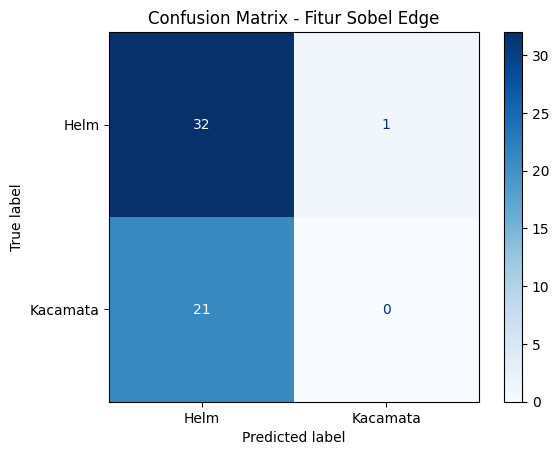


--- CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

        Helm       0.60      0.97      0.74        33
    Kacamata       0.00      0.00      0.00        21

    accuracy                           0.59        54
   macro avg       0.30      0.48      0.37        54
weighted avg       0.37      0.59      0.45        54



In [12]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

test_dir = "dataset/test"
test_files = glob.glob(os.path.join(test_dir, "*", "*.*"))

y_true = []
y_pred = []

print(f"Memproses {len(test_files)} gambar data test...")

for img_path in tqdm(test_files, desc="Evaluasi Test Data"):
    parent = os.path.basename(os.path.dirname(img_path))
    actual = "Helm" if parent.lower() == "helm" else "Kacamata"
    y_true.append(actual)
    
    # Prediksi secara diam-diam (tanpa visualisasi)
    img = cv2.imread(img_path)
    if img is not None:
        features = extract_features_sobel_no_bg(img_path).reshape(1, -1)
        pred_id = rf_model.predict(features)[0]
        pred = "Helm" if pred_id == 0 else "Kacamata"
        y_pred.append(pred)
    else:
        y_pred.append("Error")

# --- CONFUSION MATRIX & REPORT ---
labels = ["Helm", "Kacamata"]
cm = confusion_matrix(y_true, y_pred, labels=labels)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Fitur Sobel Edge")
plt.show()

print("\n--- CLASSIFICATION REPORT ---")
print(classification_report(y_true, y_pred, labels=labels, zero_division=0))